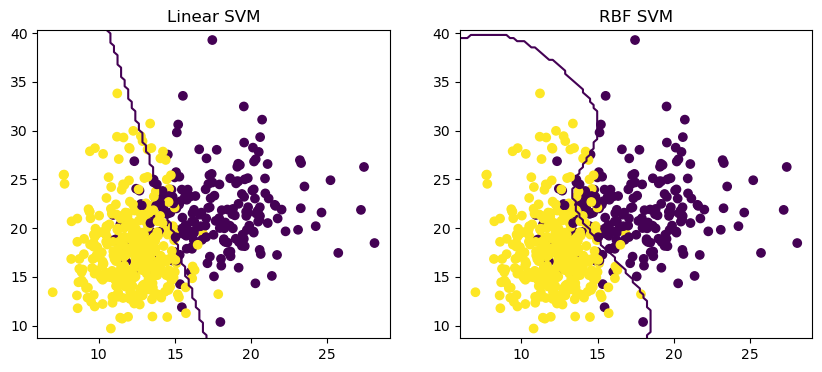

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.svm import SVC

data = load_breast_cancer()
X = data.data[:, :2]
y = data.target

linear = SVC(kernel='linear').fit(X, y)
rbf = SVC(kernel='rbf').fit(X, y)

def plot(model, title):
    plt.scatter(X[:,0], X[:,1], c=y)

    x_min, x_max = X[:,0].min()-1, X[:,0].max()+1
    y_min, y_max = X[:,1].min()-1, X[:,1].max()+1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 100),
        np.linspace(y_min, y_max, 100)
    )

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contour(xx, yy, Z, levels=[0.5])
    plt.title(title)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plot(linear, "Linear SVM")

plt.subplot(1,2,2)
plot(rbf, "RBF SVM")

plt.show()